In [1]:
import sklearn

print(sklearn.__version__)

1.9.0


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

from sklearn.datasets import fetch_california_housing


RANDOM_STATE = 42

sns.set_theme(style="whitegrid", context="notebook")

### Actividad 2

In [3]:
df_origin = fetch_california_housing(as_frame=True)
df = df_origin.frame.copy()

print(f"Dimensiones: {df.shape[0]} filas | {df.shape[1]} columnas")
print(f"Caracteristics: {df_origin.feature_names}")
df.head(5)

Dimensiones: 20640 filas | 9 columnas
Caracteristics: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
df.dtypes

MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

### Actividad 3

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MedInc,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100
HouseAge,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000
AveRooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091
AveBedrms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667
Population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000
AveOccup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333
Latitude,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000
Longitude,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000
MedHouseVal,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010


### Diagnosticar calidad

In [6]:
pd.DataFrame({
    "tipo": df.dtypes.astype("str"),
    "nulos": df.isna().sum(),
    "infinitos": np.isinf(df.select_dtypes(include=np.number)).sum(),
    "unicos": df.nunique(),
    "latitud": len(df[~df["Latitude"].between(32, 42)]),
    "longitud": len(df[~df["Longitude"].between(-125, -114)]),
})

,tipo,nulos,infinitos,unicos,latitud,longitud
MedInc,float64,0,0,12928,0,0
HouseAge,float64,0,0,52,0,0
AveRooms,float64,0,0,19392,0,0
AveBedrms,float64,0,0,14233,0,0
Population,float64,0,0,3888,0,0
AveOccup,float64,0,0,18841,0,0
Latitude,float64,0,0,862,0,0
Longitude,float64,0,0,844,0,0
MedHouseVal,float64,0,0,3842,0,0


### Detectar extremos

In [7]:
rows = []

for col in df.columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    rows.append(
        {
            "variable": col,
            "lim_inferior": lower,
            "lim_superior": upper,
            "n_outliers": int(n_out),
            "porcentaje": 100 * n_out / len(df)
        }
    )

pd.DataFrame(rows).sort_values("porcentaje", ascending=False).round(3)

,variable,lim_inferior,lim_superior,n_outliers,porcentaje
3,AveBedrms,0.866,1.240,1424,6.899
4,Population,-620.000,3132.000,1196,5.795
8,MedHouseVal,-0.981,4.824,1071,5.189
5,AveOccup,1.151,4.561,711,3.445
0,MedInc,-0.706,8.013,681,3.299
2,AveRooms,2.023,8.470,511,2.476
1,HouseAge,-10.500,65.500,0,0.000
6,Latitude,28.260,43.380,0,0.000
7,Longitude,-127.485,-112.325,0,0.000


### Actividad 6

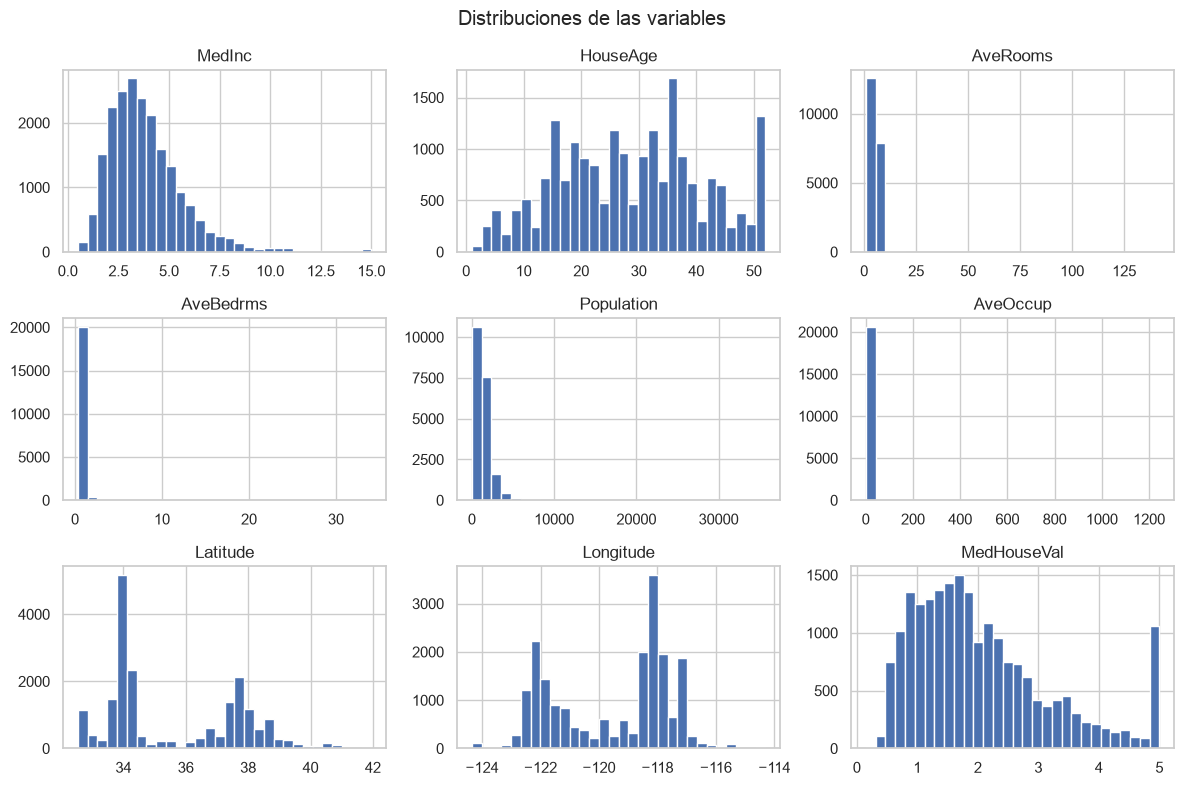

In [8]:
axes = df.hist(bins=30, figsize=(12, 8))
plt.suptitle("Distribuciones de las variables")
plt.tight_layout()
plt.show()

In [9]:
(df["MedHouseVal"] >= 5.0).mean() * 100

np.float64(4.8062015503875966)

### Actividad 7

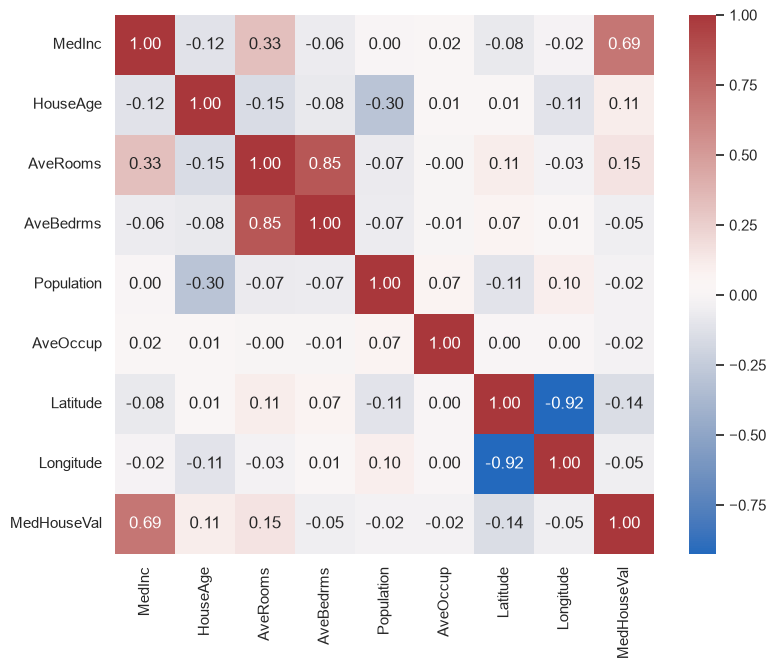

In [10]:
corr = df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, cmap="vlag", annot=True, fmt=".2f", square=True)
plt.show()

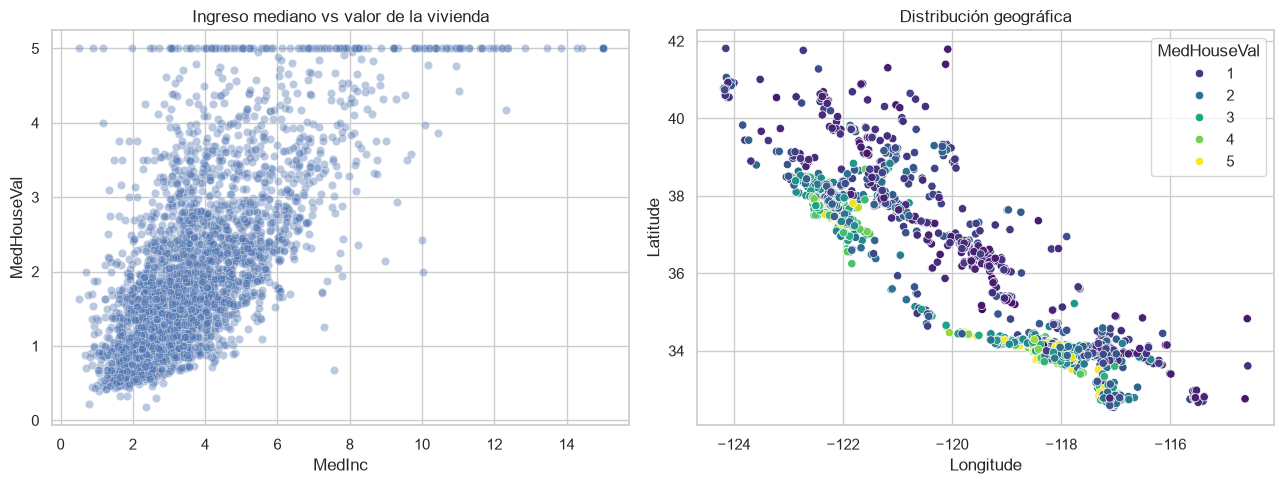

In [11]:
plot_sample = df.sample(n=3000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.scatterplot(data=plot_sample, x="MedInc", y="MedHouseVal", alpha=0.38, ax=axes[0])
axes[0].set_title("Ingreso mediano vs valor de la vivienda")

sns.scatterplot(
    data=plot_sample,
    x="Longitude",
    y="Latitude",
    hue="MedHouseVal",
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Distribución geográfica")

plt.tight_layout()
plt.show()

### Actividad 8

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="MedHouseVal")
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

print(f"Muestras totales: {X.shape}")
print(f"Muestras Train: {X_train.shape}")
print(f"Muestras Test: {X_test.shape}")

print(f"Media train: {y_train.mean():.3f}")
print(f"Media test: {y_test.mean():.3f}")

Muestras totales: (20640, 8)
Muestras Train: (16512, 8)
Muestras Test: (4128, 8)
Media train: 2.072
Media test: 2.055


### Actividad 9

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, ElasticNet, Lasso, Ridge

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [14]:

def make_pipeline(modelo):
    pipeline = Pipeline(
        [
            (
                "prep", Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler())
                ])
            ),
            (
                ("model", modelo)
            )
        ]
    )
    return pipeline

prepro_pipeline = make_pipeline(LinearRegression()).named_steps["prep"]
prepro_pipeline.fit(X_train)

print("means: ", prepro_pipeline.named_steps["scaler"].mean_)
print("std: ", prepro_pipeline.named_steps["scaler"].scale_)

X_train_scaled = prepro_pipeline.transform(X_train)

means:  [ 3.88075426e+00  2.86082849e+01  5.43523502e+00  1.09668475e+00
  1.42645300e+03  3.09696119e+00  3.56431492e+01 -1.19582290e+02]
std:  [1.90423626e+00 1.26021177e+01 2.38730258e+00 4.33201426e-01
 1.13702195e+03 1.15783935e+01 2.13660060e+00 2.00559281e+00]


In [15]:
stats_df = pd.DataFrame({
    "media": X_train_scaled.mean(axis=0),
    "std": X_train_scaled.std(axis=0)
}, index=X_train.columns)
stats_df.round(3)

,media,std
MedInc,-0.0,1.0
HouseAge,-0.0,1.0
AveRooms,0.0,1.0
AveBedrms,-0.0,1.0
Population,0.0,1.0
AveOccup,0.0,1.0
Latitude,0.0,1.0
Longitude,0.0,1.0


### Actividad 10

In [16]:
def get_metricas(nombre, model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "modelo": nombre,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred),
        "R2": r2_score(y_test, y_pred)
    }

baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)
baseline_metrics = get_metricas("baseline (media)", baseline, X_test, y_test)

pd.DataFrame([baseline_metrics]).set_index("modelo").round(3)

,MAE,RMSE,R2
modelo,,,
baseline (media),0.906,1.145,-0.0


### Actividad 11

In [17]:
ols_pipeline = make_pipeline(LinearRegression())
ols_pipeline.fit(X_train, y_train)

ols_metrics = get_metricas("OLS", ols_pipeline, X_test, y_test)

pd.DataFrame([baseline_metrics, ols_metrics]).set_index("modelo").round(3)

,MAE,RMSE,R2
modelo,,,
baseline (media),0.906,1.145,-0.000
OLS,0.533,0.746,0.576


### Actividad 13

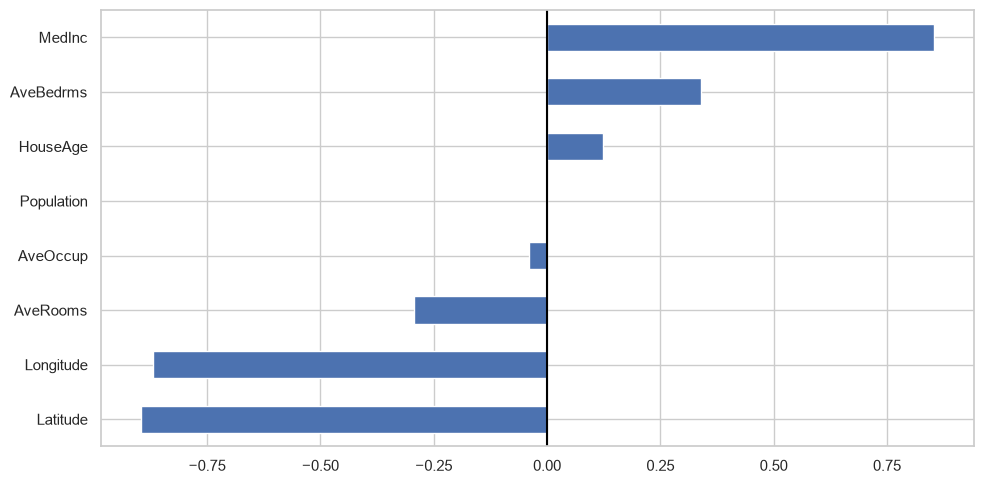

Latitude     -0.896929
Longitude    -0.869842
MedInc        0.854383
AveBedrms     0.339259
AveRooms     -0.294410
HouseAge      0.122546
AveOccup     -0.040829
Population   -0.002308
dtype: float64

In [18]:
sk_model = ols_pipeline.named_steps["model"]
coef_ols = pd.Series(sk_model.coef_, index=X.columns)
coef_ols.sort_values().plot(kind="barh", figsize=(10, 5))
plt.axvline(0, color="black")
plt.tight_layout()
plt.show()

coef_ols.sort_values(key=np.abs, ascending=False)

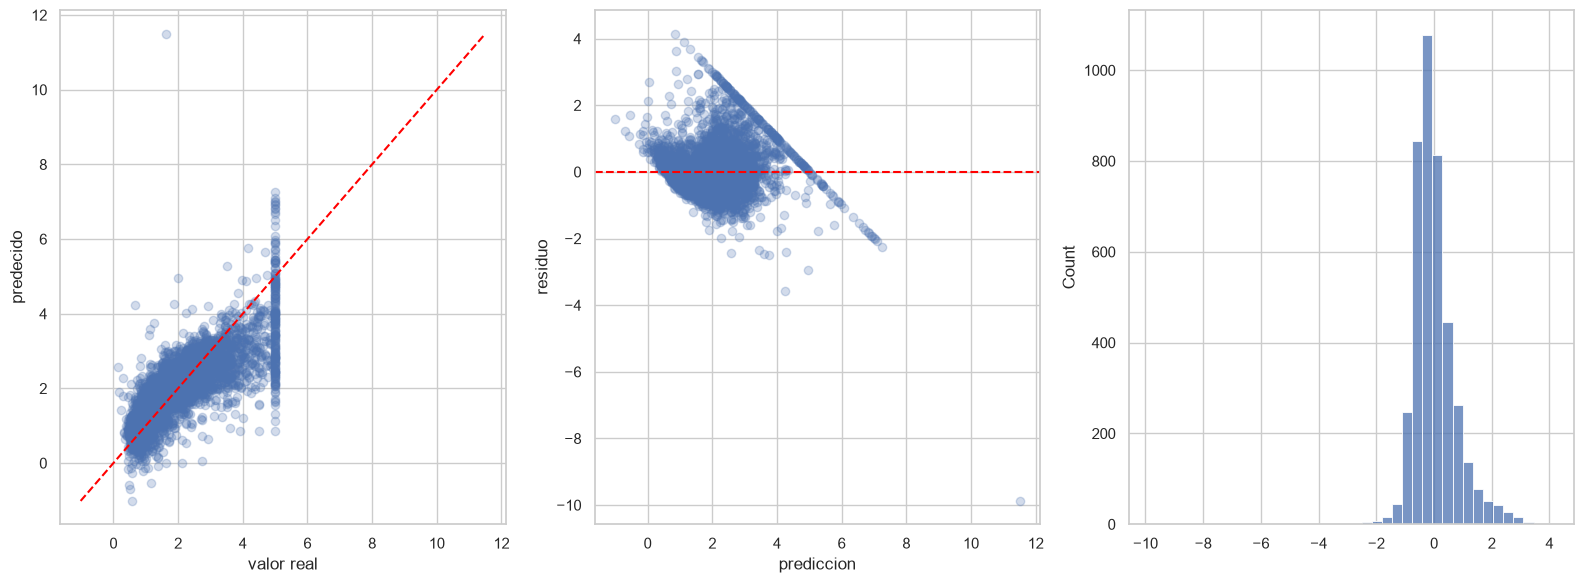

In [19]:
y_preds_ols = ols_pipeline.predict(X_test)
residuos = y_test.to_numpy() - y_preds_ols

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

axes[0].scatter(y_test, y_preds_ols, alpha=0.25)
lims = [min(y_test.min(), y_preds_ols.min()),
        max(y_test.max(), y_preds_ols.max())]
axes[0].plot(lims, lims, '--', color='red')
axes[0].set(xlabel="valor real", ylabel="predecido")

axes[1].scatter(y_preds_ols, residuos, alpha=0.25)
axes[1].axhline(0, color="red", linestyle='--')
axes[1].set(xlabel="prediccion", ylabel="residuo")

sns.histplot(residuos, bins=40)

plt.tight_layout()
plt.show()

### Actividad 15 / 16 / 17 / 18 / 19

In [20]:
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV

# validacion cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

models = {
    "ridge": GridSearchCV(
        make_pipeline(Ridge()),
        {
            "model__alpha": np.logspace(-4, 3, 20)
        },
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    ),

    "lasso": GridSearchCV(
        make_pipeline(Lasso(max_iter=50000)),
        {
            "model__alpha": np.logspace(-4, 1, 20)
        },
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    ),

    "elasticnet": GridSearchCV(
        make_pipeline(ElasticNet()),
        {
            "model__alpha": np.logspace(-4, 1, 20),
            "model__l1_ratio": (0.1, 0.5, 0.9)
        },
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} | mejor RMSE={-model.best_score_:.6f} best_params:{model.best_params_}")

ridge | mejor RMSE=0.720509 best_params:{'model__alpha': np.float64(2.6366508987303554)}
lasso | mejor RMSE=0.720494 best_params:{'model__alpha': np.float64(0.0006158482110660267)}
elasticnet | mejor RMSE=0.720496 best_params:{'model__alpha': np.float64(0.0006158482110660267), 'model__l1_ratio': 0.9}


In [21]:
ols_metrics

{'modelo': 'OLS',
 'MAE': 0.5332001304956565,
 'RMSE': 0.7455813830127764,
 'R2': 0.5757877060324508}

In [22]:
rows = [baseline_metrics, ols_metrics]
for name, model in models.items():
    rows.append(
        get_metricas(name, model.best_estimator_, X_test, y_test)
    )

pd.DataFrame(rows).set_index("modelo").sort_values("RMSE")

,MAE,RMSE,R2
modelo,,,
lasso,0.533161,0.744991,0.576459
elasticnet,0.533158,0.745026,0.576420
ridge,0.533182,0.745517,0.575861
OLS,0.533200,0.745581,0.575788
baseline (media),0.906069,1.144856,-0.000219


### Actividad 20

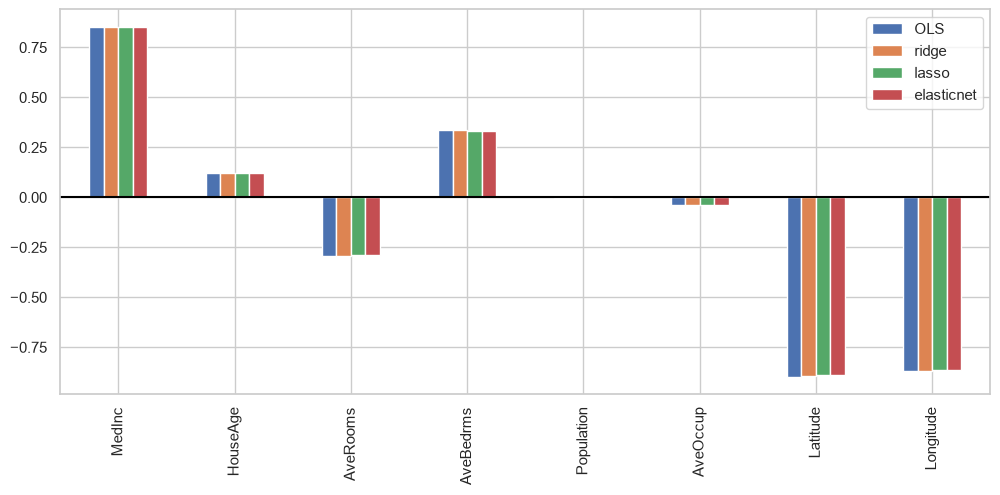

In [23]:
coef_models = {
    "OLS": ols_pipeline.named_steps["model"].coef_
}

for name, model in models.items():
    coef_models[name] = model.best_estimator_.named_steps["model"].coef_

coef_table = pd.DataFrame(coef_models, index=X.columns)
coef_table.plot(kind="bar", figsize=(12, 5))
plt.axhline(0, color="black")
plt.show()

In [24]:
coef_table

,OLS,ridge,lasso,elasticnet
MedInc,0.854383,0.854234,0.851160,0.851427
HouseAge,0.122546,0.122751,0.123040,0.123069
AveRooms,-0.294410,-0.293883,-0.286329,-0.286939
AveBedrms,0.339259,0.338596,0.331131,0.331694
Population,-0.002308,-0.002241,-0.001540,-0.001591
AveOccup,-0.040829,-0.040839,-0.040251,-0.040313
Latitude,-0.896929,-0.894925,-0.890076,-0.889992
Longitude,-0.869842,-0.867812,-0.862595,-0.862541


### Actividad 21

In [25]:
muestra = X_test.iloc[[5]]
valor_real = y_test.iloc[5] * 100000

pred = ols_pipeline.predict(muestra) * 100000
print("Valor predecido: ", pred[0], "Valor real: ", valor_real)

Valor predecido:  201175.3673249894 Valor real:  158700.0


### Actividad 22

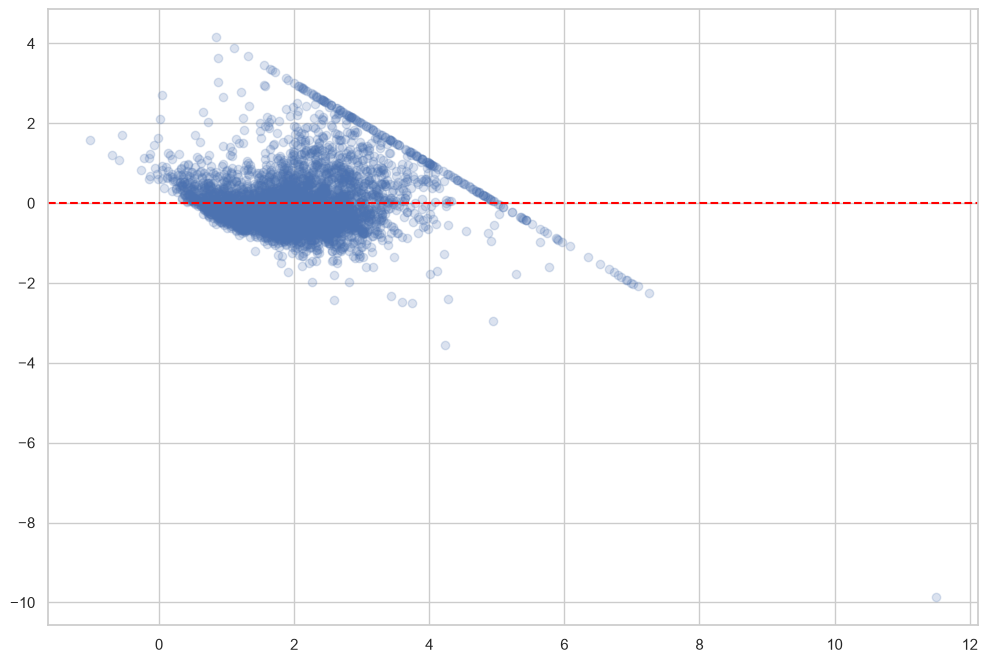

Error promedio de 20% más barato: 0.102
Error promedio de 20% más caros: 0.113


In [26]:
preds = ols_pipeline.predict(X_test)
residuos = (y_test - preds).to_numpy()

plt.figure(figsize=(12, 8))
plt.scatter(preds, residuos, alpha=0.2)
plt.axhline(0, color="red", linestyle="--")
plt.show()

orden = np.argsort(preds)
n = len(preds) // 5

print(f"Error promedio de 20% más barato: {residuos[orden[:n]].mean():.3f}")
print(f"Error promedio de 20% más caros: {residuos[orden[-n:]].mean():.3f}")


### Actividad 23

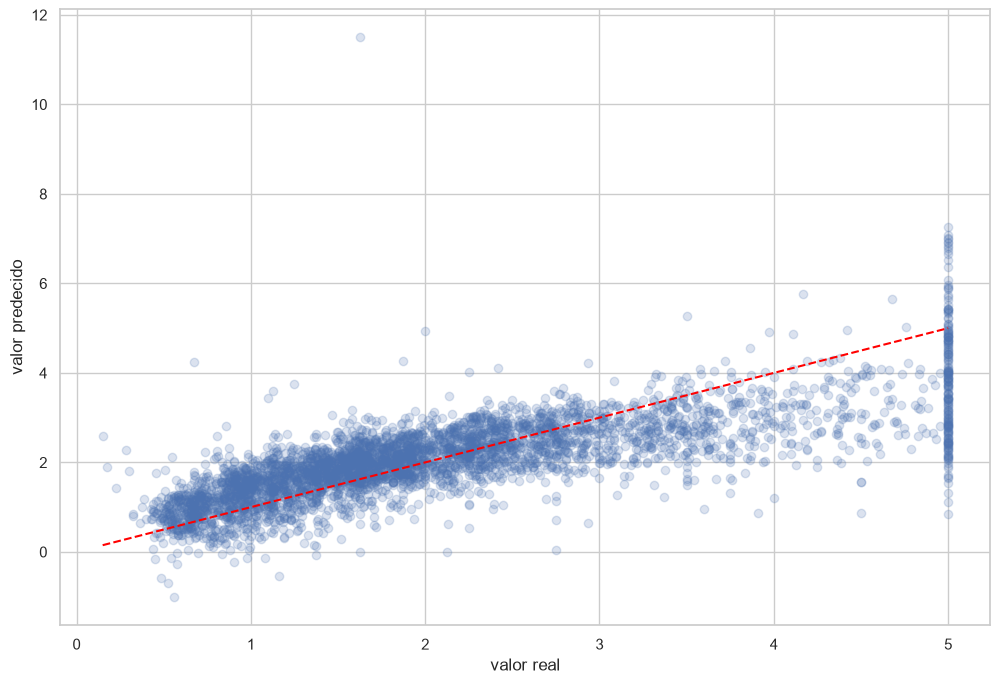

In [27]:
plt.figure(figsize=(12, 8))
plt.scatter(y_test, preds, alpha=0.2)

lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, "--", color="red")
plt.xlabel("valor real")
plt.ylabel("valor predecido")
plt.show()

In [28]:
muestras_tope_5 = (y_test >= 5.0).mean() * 100
muestras_tope_5

np.float64(4.457364341085271)

### Actividad 24

In [29]:
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline

splines = make_pipeline(
    SplineTransformer(n_knots=6),
    Ridge(alpha=1.0)
)
splines.fit(X_train, y_train)

r2_splines = splines.score(X_test, y_test)
splines_metrics = get_metricas("splines", splines, X_test, y_test)

print(f"R2 OLS: {ols_metrics["R2"]}")
print(f"R2 SPLINES: {r2_splines}")

print(f"MAE OLS: {ols_metrics["MAE"]}")
print(f"MAE SPLINES: {splines_metrics["MAE"]}")

print(f"RMSE OLS: {ols_metrics["RMSE"]}")
print(f"RMSE SPLINES: {splines_metrics["RMSE"]}")

print("Ganancia:", abs(ols_metrics["R2"] - r2_splines))

# splines_metrics

R2 OLS: 0.5757877060324508
R2 SPLINES: 0.6336772343948947
MAE OLS: 0.5332001304956565
MAE SPLINES: 0.4979303431499082
RMSE OLS: 0.7455813830127764
RMSE SPLINES: 0.6928438792274683
Ganancia: 0.057889528362443876


In [30]:
filas = []
tramos = [3, 6, 10, 15, 20, 30, 40, 50, 100, 200, 300, 500, 800, 1000]

for tramo in tramos:
    modelo = make_pipeline(SplineTransformer(n_knots=tramo), Ridge(alpha=1))
    modelo.fit(X_train, y_train)
    # exps.append(get_metricas(f"tramo_{tramo}", modelo, X_test, y_test))
    filas.append({
        "tramos": tramo,
        "r2_train": modelo.score(X_train, y_train),
        "rmse_train": root_mean_squared_error(y_train, modelo.predict(X_train)),
        "r2_test": modelo.score(X_test, y_test),
        "rmse_test": root_mean_squared_error(y_test, modelo.predict(X_test))
    })

filas = pd.DataFrame(filas)

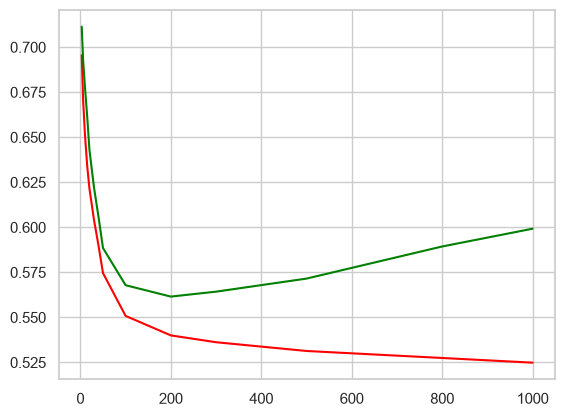

In [31]:
plt.plot(tramos, filas["rmse_train"].to_numpy(), color="red")
plt.plot(tramos, filas["rmse_test"].to_numpy(), color="green")

### Actividad 26

In [32]:
from sklearn.neighbors import KNeighborsRegressor

vecinos = make_pipeline(
    StandardScaler(),
    KNeighborsRegressor(n_neighbors=10)
)

vecinos.fit(X_train, y_train)
r2_vecinos = vecinos.score(X_test, y_test)

print(f"r2_lineal: ", ols_metrics["R2"])
print(f"r2_splines: ", r2_splines)
print(f"r2_vecinos: ", r2_vecinos)

r2_lineal:  0.5757877060324508
r2_splines:  0.6336772343948947
r2_vecinos:  0.678313939893506


In [33]:
vecinos_sin_scalar = make_pipeline(
    KNeighborsRegressor(n_neighbors=10)
)
vecinos_sin_scalar.fit(X_train, y_train)
r2_vecinos_sin_scalar = vecinos_sin_scalar.score(X_test, y_test)

print(f"r2_vecinos_con_standarizacion: ", r2_vecinos)
print(f"r2_vecinos_sin_standarizacion: ", r2_vecinos_sin_scalar)

r2_vecinos_con_standarizacion:  0.678313939893506
r2_vecinos_sin_standarizacion:  0.15538785394268484


In [34]:
X_train.std().sort_values(ascending=False)

Population    1137.056380
HouseAge        12.602499
AveOccup        11.578744
AveRooms         2.387375
Latitude         2.136665
Longitude        2.005654
MedInc           1.904294
AveBedrms        0.433215
dtype: float64

In [35]:
filas = []
vecinos = [1, 5, 10, 25, 50, 100, 150, 200]

for k in vecinos:
    modelo = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=k))
    modelo.fit(X_train, y_train)
    filas.append({
        "n_neighbors": k,
        "r2_entrenamiento": modelo.score(X_train, y_train),
        "rmse_train": root_mean_squared_error(y_train, modelo.predict(X_train)),
        "r2_prueba": modelo.score(X_test, y_test),
        "rmse_test": root_mean_squared_error(y_test, modelo.predict(X_test))
    })

filas = pd.DataFrame(filas)
filas

,n_neighbors,r2_entrenamiento,rmse_train,r2_prueba,rmse_test
0,1,1.000000,0.000000,0.489463,0.817932
1,5,0.796898,0.521059,0.670010,0.657588
2,10,0.754979,0.572310,0.678314,0.649261
3,25,0.714814,0.617439,0.674508,0.653091
4,50,0.688864,0.644919,0.659440,0.668037
5,100,0.665466,0.668728,0.642517,0.684433
6,150,0.650153,0.683862,0.630345,0.695988
7,200,0.638428,0.695227,0.619545,0.706082


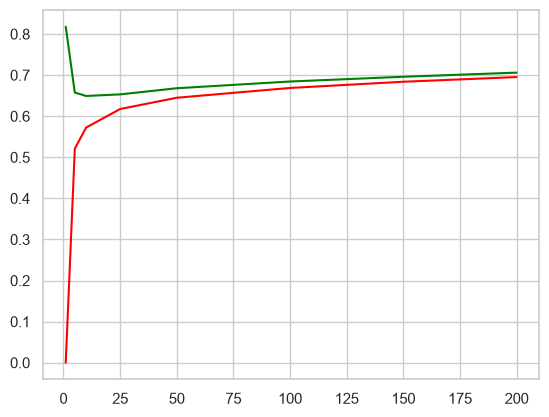

In [36]:
plt.plot(vecinos, filas["rmse_train"].to_numpy(), color="red")
plt.plot(vecinos, filas["rmse_test"].to_numpy(), color="green")

### Actividad 29 y 30

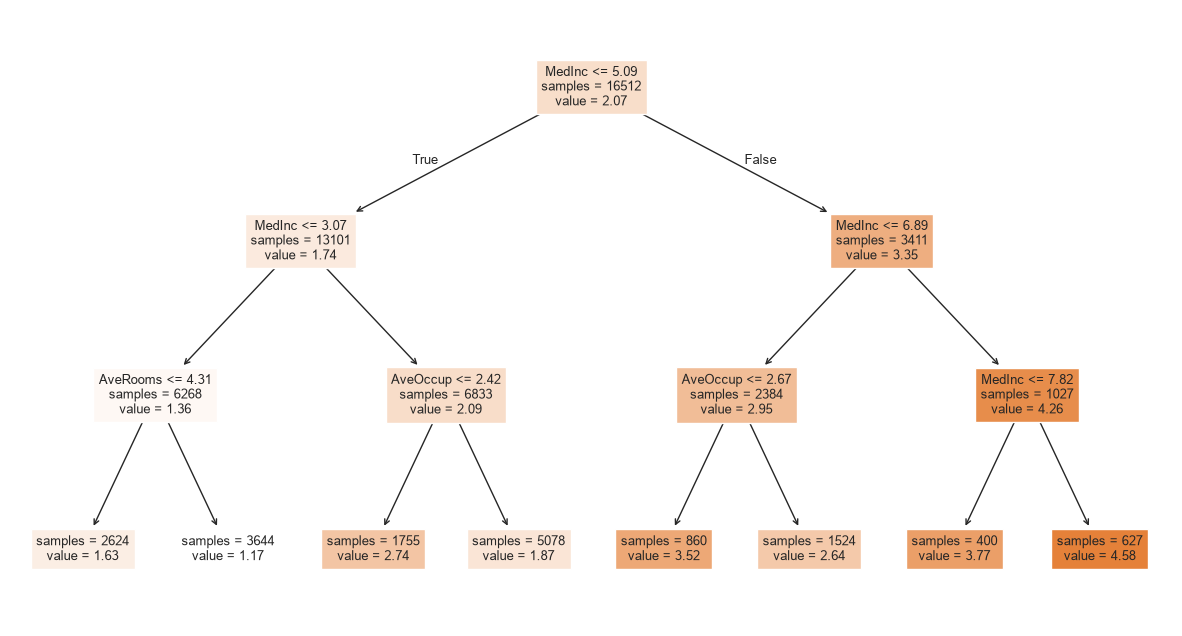

In [37]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

arbol_3 = DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE)
arbol_3.fit(X_train, y_train)

plt.figure(figsize=(15, 8))
plot_tree(arbol_3, feature_names=list(X_train.columns), filled=True, fontsize=9, impurity=False, precision=2)
plt.show()

In [38]:
r2_arbol_3 = arbol_3.score(X_test, y_test)
print(f"r2 lineal: {ols_metrics["R2"]}")
print(f"r2 splines: {r2_splines}")
print(f"r2_vecinos_con_standarizacion: ", r2_vecinos)
print(f"r2_arbol_3: ", r2_arbol_3)

r2 lineal: 0.5757877060324508
r2 splines: 0.6336772343948947
r2_vecinos_con_standarizacion:  0.678313939893506
r2_arbol_3:  0.5097629887358219


In [39]:
arbol_5 = DecisionTreeRegressor(max_depth=5, random_state=RANDOM_STATE)
arbol_5.fit(X_train, y_train)

r2_arbol_5 = arbol_5.score(X_test, y_test)
print(f"r2 lineal: {ols_metrics["R2"]}")
print(f"r2 splines: {r2_splines}")
print(f"r2_vecinos_con_standarizacion: ", r2_vecinos)
print(f"r2_arbol_3: ", r2_arbol_3)
print(f"r2_arbol_5: ", r2_arbol_5)


r2 lineal: 0.5757877060324508
r2 splines: 0.6336772343948947
r2_vecinos_con_standarizacion:  0.678313939893506
r2_arbol_3:  0.5097629887358219
r2_arbol_5:  0.5997321244428706


In [40]:
arbol_sin_limite = DecisionTreeRegressor(max_depth=None, random_state=RANDOM_STATE)
arbol_sin_limite.fit(X_train, y_train)

r2_arbol_sin_limite = arbol_sin_limite.score(X_test, y_test)

print(f"r2 lineal: {ols_metrics["R2"]}")
print(f"r2 splines: {r2_splines}")
print(f"r2_vecinos_con_standarizacion: ", r2_vecinos)
print(f"r2_arbol_3: ", r2_arbol_3)
print(f"r2_arbol_5: ", r2_arbol_5)
print(f"r2_arbol_sin_limite: ", r2_arbol_sin_limite)

r2 lineal: 0.5757877060324508
r2 splines: 0.6336772343948947
r2_vecinos_con_standarizacion:  0.678313939893506
r2_arbol_3:  0.5097629887358219
r2_arbol_5:  0.5997321244428706
r2_arbol_sin_limite:  0.6160675721345087


In [41]:
arbol_sin_limite.get_depth()

34

### Actividad 31

In [47]:
from sklearn.ensemble import RandomForestRegressor

bosque = RandomForestRegressor(
    n_estimators=300,
    random_state=RANDOM_STATE
)

bosque.fit(X_train, y_train)

r2_bosque = bosque.score(X_test, y_test)

print(f"r2 lineal: {ols_metrics["R2"]}")
print(f"r2 splines: {r2_splines}")
print(f"r2_vecinos_con_standarizacion: ", r2_vecinos)
print("R2 bosque: ", r2_bosque)

r2 lineal: 0.5757877060324508
r2 splines: 0.6336772343948947
r2_vecinos_con_standarizacion:  0.678313939893506
R2 bosque:  0.8062927130336361


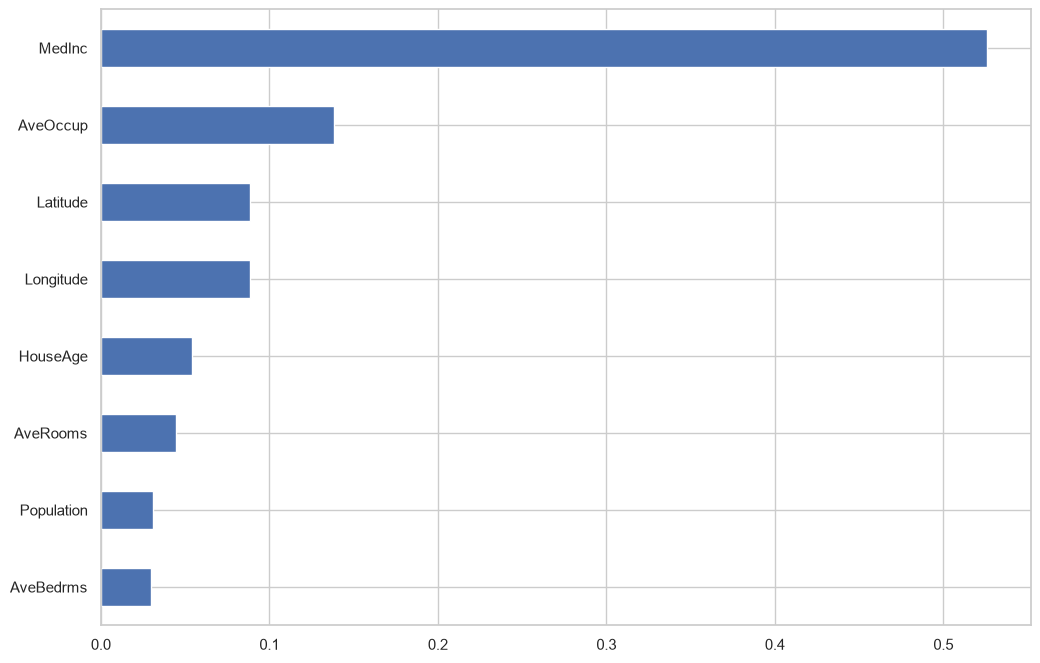

In [48]:
importancias = pd.Series(bosque.feature_importances_, index=X_train.columns)
importancias.sort_values().plot(kind="barh", figsize=(12,8))
plt.show()

In [50]:
importancias.sort_values()

AveBedrms     0.029692
Population    0.030621
AveRooms      0.044545
HouseAge      0.054248
Longitude     0.088529
Latitude      0.088599
AveOccup      0.138100
MedInc        0.525667
dtype: float64

### Actividad 32

In [52]:
from sklearn.ensemble import HistGradientBoostingRegressor
import time

start_time = time.perf_counter()
boosting = HistGradientBoostingRegressor(random_state=RANDOM_STATE)
boosting.fit(X_train, y_train)
end_time = time.perf_counter()

tiempo_total = end_time - start_time

r2_boosting = boosting.score(X_test, y_test)

print(f"r2 lineal: {ols_metrics["R2"]}")
print(f"r2 splines: {r2_splines}")
print(f"r2_vecinos_con_standarizacion: ", r2_vecinos)
print("R2 bosque: ", r2_bosque)
print("R2 boosting: ", r2_boosting)
print(f"r2_arbol_sin_limite: ", r2_arbol_sin_limite)
print("Tiempo entrenamiento de boosting: ", tiempo_total)

r2 lineal: 0.5757877060324508
r2 splines: 0.6336772343948947
r2_vecinos_con_standarizacion:  0.678313939893506
R2 bosque:  0.8062927130336361
R2 boosting:  0.8347108310143663
r2_arbol_sin_limite:  0.6160675721345087
Tiempo entrenamiento de boosting:  1.1736698329914361


In [76]:
muestra_test = X_test.iloc[0, :].to_numpy().reshape(1,-1)
etiqueta_test = y_test.iloc[0]

pred_ols = ols_pipeline.predict(muestra_test)
pred_boosting = boosting.predict(muestra_test)

/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
/Users/marcell/Documents/codigo_by_tecsup/datascience-g8/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but HistGradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [77]:

print("Valor real: ", etiqueta_test * 100000)
print("Prediccion_lineal: ", pred_ols * 100000)
print("Prediccion_boosting: ", pred_boosting * 100000)


Valor real:  47700.0
Prediccion_lineal:  [71912.28416019]
Prediccion_boosting:  [57313.49339984]
